## Step 2: Exploratory Data Analysis (EDA) on Dataset

1. **Check ham vs. spam distribution**
2. **Create three new columns** from the input column:
   - `count_alphabet`
   - `count_words`
   - `count_sentence`
3. **Analyze the distribution** of these three new columns
4. **Find the most frequent words** in ham and spam texts

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
df = pd.read_csv("../data/cleaned/cleaned.csv")
df.sample(5)

,target,text
2598,0,Go where n buy? Juz buy when we get there lar.
1665,0,Am watching house ÛÒ very entertaining ÛÒ am...
487,0,Got meh... When?
4529,0,I'm fine. Hope you are also
1219,0,"Not yet chikku..going to room nw, i'm in bus.."


In [71]:
# Checking ham and spam distribution
# ham -> 0
# spam -> 1
df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

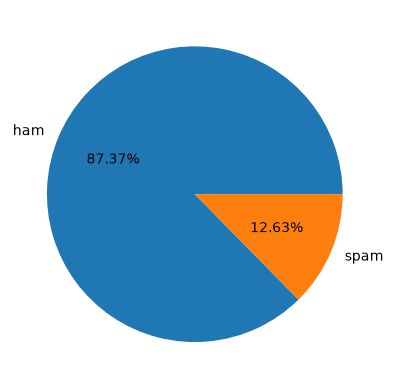

In [72]:
plt.pie(
  df["target"].value_counts(), 
  labels=["ham", "spam"],
  autopct="%1.2f%%"
)

### Adding count_alphabet column

In [73]:
df["count_alphabet"] = df["text"].apply(lambda x: len(x))

In [74]:
df.sample(3)

,target,text,count_alphabet
1568,0,Friends that u can stay on fb chat with,39
2849,0,"Oh, then your phone phoned me but it disconnected",49
106,0,How would my ip address test that considering ...,82


In [75]:
ham_avg_alp = df[df["target"] == 0]["count_alphabet"].mean()
spam_avg_alp = df[df["target"] == 1]["count_alphabet"].mean()

In [76]:
def bar_plot(category: list, values: list) -> None:
  bar = plt.bar(category, values)
  plt.bar_label(bar, label_type="center")
  plt.show()

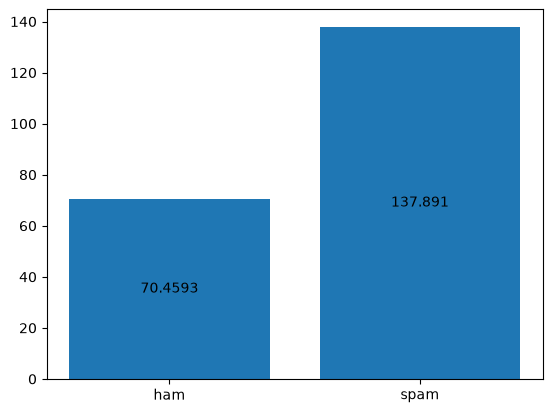

In [77]:
bar_plot(
  category= ["ham", "spam"],
  values= [ham_avg_alp, spam_avg_alp]
)

In [101]:
def plot_hist(column: str)-> None:
  sns.histplot(data=df, x=column, hue="target")
  plt.legend(title="Type", labels=["Spam", "Ham"])

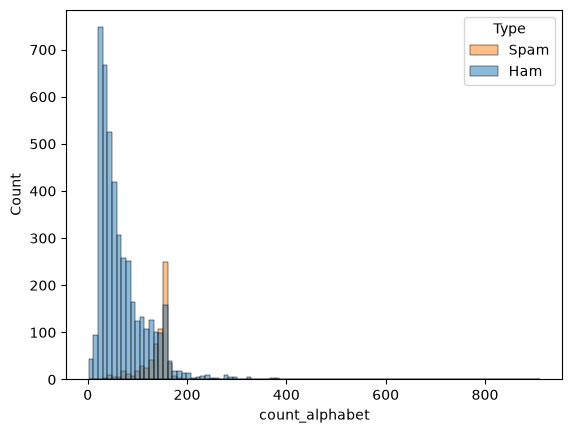

In [102]:
plot_hist(column= "count_alphabet")

### Adding count words column

In [78]:
import nltk
from nltk.tokenize import word_tokenize

In [79]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/omveersingh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/omveersingh/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [80]:
df["count_words"] = df["text"].apply(lambda x: len(word_tokenize(x)))

In [81]:
df.sample(3)

,target,text,count_alphabet,count_words
134,0,I only haf msn. It's yijue@hotmail.com,38,10
1481,0,I think chennai well settled?,29,6
3856,1,HOT LIVE FANTASIES call now 08707500020 Just 2...,122,25


In [82]:
ham_avg_word = df[df["target"] == 0]["count_words"].mean()
spam_avg_word = df[df["target"] == 1]["count_words"].mean()

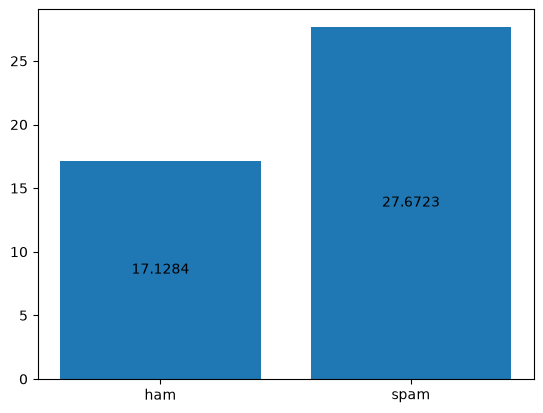

In [83]:
bar_plot(
  category=["ham", "spam"],
  values= [ham_avg_word, spam_avg_word]
)

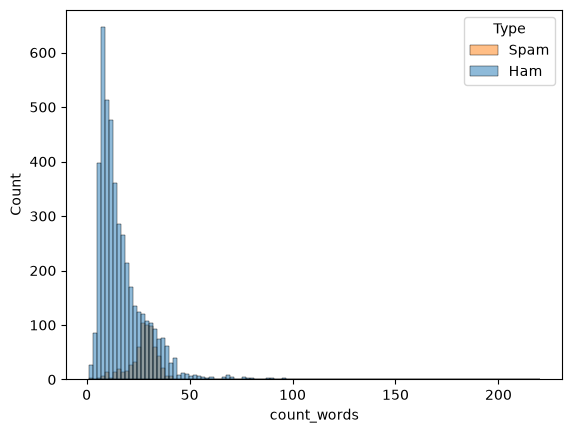

In [103]:
plot_hist(column= "count_words")

### Adding count_sentence column

In [84]:
from nltk.tokenize import sent_tokenize

In [85]:
df["count_sent"] = df["text"].apply(lambda x: len(sent_tokenize(x)))

In [86]:
df.sample(3)

,target,text,count_alphabet,count_words,count_sent
3211,0,Heehee that was so funny tho,28,6,1
106,0,How would my ip address test that considering ...,82,15,1
554,1,GENT! We are trying to contact you. Last weeke...,160,33,7


In [87]:
ham_avg_sent = df[df["target"] == 0]["count_sent"].mean()
spam_avg_sent = df[df["target"] == 1]["count_sent"].mean()

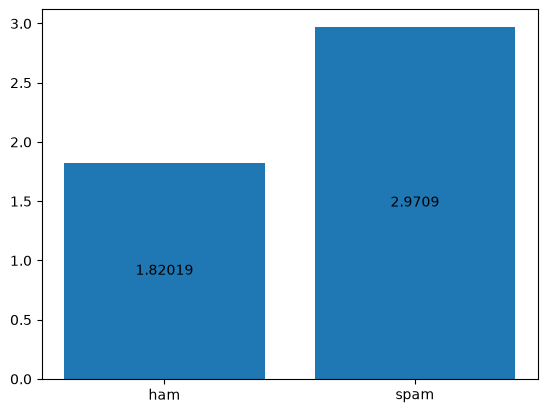

In [88]:
bar_plot(
  category= ["ham", "spam"],
  values=[ham_avg_sent, spam_avg_sent]
)

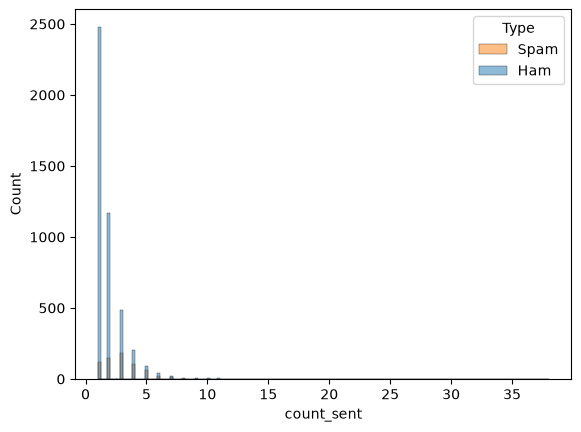

In [104]:
plot_hist(column= "count_sent")

### comparing all three columns at once

In [89]:
data = df[["target", "count_alphabet", "count_words", "count_sent"]].corr()
data

,target,count_alphabet,count_words,count_sent
target,1.000000,0.384717,0.262720,0.263939
count_alphabet,0.384717,1.000000,0.965686,0.624139
count_words,0.262720,0.965686,1.000000,0.679767
count_sent,0.263939,0.624139,0.679767,1.000000


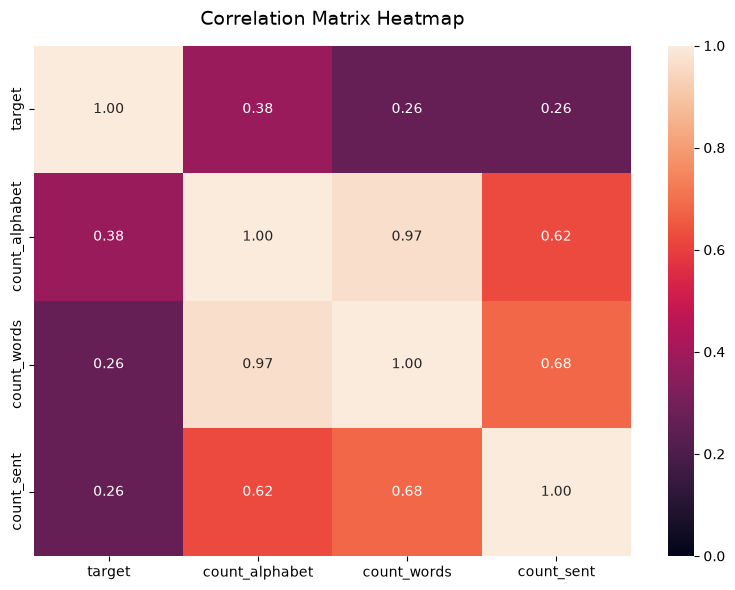

In [90]:
labels = ["target", "count_alphabet", "count_words", "count_sent"]

plt.figure(figsize=(8, 6))

sns.heatmap(data, annot=True, fmt=".2f",xticklabels=labels, yticklabels=labels,vmin=0, vmax=1)

plt.title("Correlation Matrix Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


In [105]:
df.to_csv("../data/cleaned/cleaned2.csv", index= False)

In [131]:
from collections import Counter
from nltk.corpus import stopwords
import string

nltk.download("stopwords")
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/omveersingh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [134]:
spam_words = " ".join(df[df["target"] == 1]["text"]).split(" ")
spam_words = [word.lower() for word in spam_words if (word not in stop_words and word not in string.punctuation)]

In [135]:
Counter(spam_words).most_common()

[('call', 298),
 ('free', 157),
 ('2', 151),
 ('ur', 119),
 ('txt', 114),
 ('text', 96),
 ('u', 96),
 ('mobile', 95),
 ('reply', 93),
 ('claim', 89),
 ('stop', 83),
 ('you', 76),
 ('4', 75),
 ('your', 70),
 ('to', 69),
 ('get', 68),
 ('new', 64),
 ('send', 55),
 ('prize', 53),
 ('nokia', 53),
 ('now!', 53),
 ('contact', 51),
 ('please', 47),
 ('cash', 47),
 ('win', 46),
 ('service', 42),
 ('urgent!', 39),
 ('per', 39),
 ('this', 38),
 ('customer', 33),
 ('we', 32),
 ('draw', 32),
 ('chat', 32),
 ('phone', 32),
 ('awarded', 31),
 ('for', 30),
 ('tone', 30),
 ('latest', 29),
 ('shows', 29),
 ('want', 28),
 ('receive', 27),
 ('å£1000', 27),
 ('video', 27),
 ('i', 26),
 ('150ppm', 26),
 ('holiday', 26),
 ('go', 26),
 ('box', 26),
 ('every', 26),
 ('1', 25),
 ('week', 25),
 ('number', 25),
 ('po', 24),
 ('just', 24),
 ('guaranteed', 23),
 ('now', 23),
 ('tones', 23),
 ('you!', 23),
 ('message', 22),
 ('entry', 21),
 ('network', 21),
 ('selected', 21),
 ('valid', 21),
 ('the', 21),
 ('find',

In [136]:
ham_words = " ".join(df[df["target"] == 0]["text"]).split(" ")
ham_words = [word.lower() for word in ham_words if (word not in stop_words and word not in string.punctuation)]

In [137]:
Counter(ham_words).most_common()

[('i', 1349),
 ('u', 794),
 ('get', 285),
 ('2', 272),
 ("i'm", 269),
 ('&lt;#&gt;', 254),
 ('go', 227),
 ('got', 221),
 ('like', 212),
 ('come', 199),
 ('know', 197),
 ('ur', 195),
 ('you', 194),
 ('good', 171),
 ('call', 170),
 ('...', 159),
 ('going', 152),
 ('4', 151),
 ('want', 149),
 ('ok', 146),
 ('time', 145),
 ('need', 143),
 ('love', 139),
 ('still', 139),
 ('how', 135),
 ('one', 134),
 ('but', 127),
 ('think', 122),
 ('see', 122),
 ('r', 120),
 ('so', 119),
 ('n', 118),
 ('dont', 115),
 ('tell', 114),
 ('take', 107),
 ('if', 107),
 ("i'll", 106),
 ('no', 106),
 ('send', 106),
 ('home', 105),
 ('ì_', 105),
 ('and', 103),
 ('do', 99),
 ('back', 99),
 ('what', 97),
 ('my', 96),
 ('hope', 95),
 ('just', 92),
 ('day', 91),
 ('hi', 90),
 ('much', 88),
 ('the', 88),
 ('give', 87),
 ('make', 85),
 ('me.', 84),
 ('are', 84),
 ('ask', 84),
 ('sorry', 84),
 ('da', 82),
 ('have', 80),
 ('happy', 80),
 ('we', 80),
 ('e', 77),
 ('really', 77),
 ('hey', 77),
 ('you.', 75),
 ('well', 75),
 

In [152]:
from wordcloud import WordCloud

def plot_word_cloud(text: list, size: tuple = (10, 5)) -> None:
  wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white'
  ).generate_from_frequencies(Counter(text))

  plt.figure(figsize=size)
  plt.imshow(wordcloud, interpolation="bilinear")
  plt.axis("off")
  plt.show()

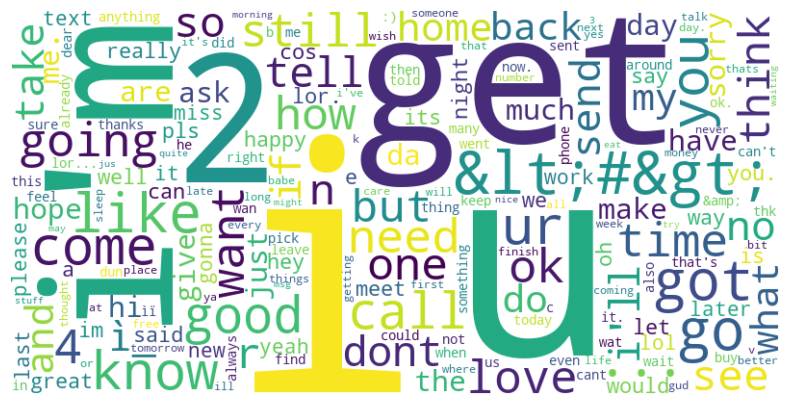

In [153]:
plot_word_cloud(text= ham_words)

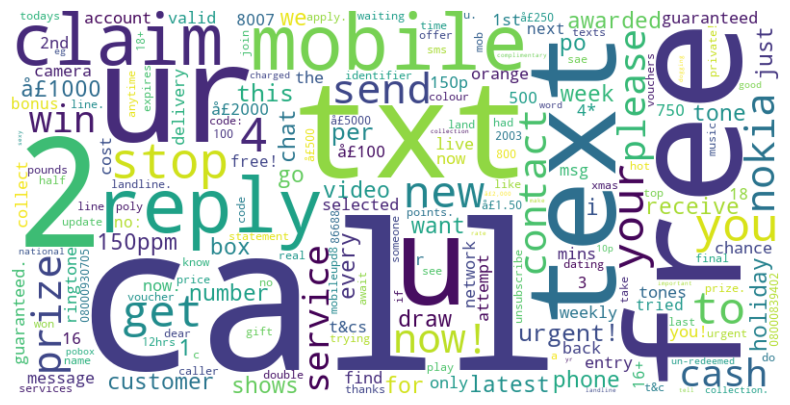

In [154]:
plot_word_cloud(text= spam_words)

## 🔍 Exploratory Data Analysis (EDA)

> Key insights uncovered before modeling — understanding the data shaped feature engineering and model choice.

---

### 🟢🔴 Class Distribution

The dataset is **imbalanced**, which directly influenced the choice of evaluation metrics (precision/recall over raw accuracy).

| Class | Proportion |
| :--- | :--- |
| 🟢 Ham | ~87% |
| 🔴 Spam | ~13% |

<div align="center">
<img src="assets/class_distribution.png" alt="Class Distribution" width="500"/>
</div>

---

### ✉️ Message Length

Spam messages tend to run **noticeably longer** than genuine ones — likely due to promotional filler text and links.

| Class | Avg. Length (characters) |
| :--- | :--- |
| 🔴 Spam | ~140 |
| 🟢 Ham | ~70 |

<div align="center">
<img src="assets/message_length_distribution.png" alt="Message Length Distribution" width="480"/>
<img src="assets/message_length_boxplot.png" alt="Message Length Boxplot" width="480"/>
</div>

---

### 🔤 Word Frequency

> [!TIP]
> Spam vocabulary skews toward urgency and reward-based language, while Ham vocabulary reflects everyday conversation.

<table align="center">
<tr>
<th align="center">🔴 Spam — Common Words</th>
<th align="center">🟢 Ham — Common Words</th>
</tr>
<tr>
<td align="center"><code>free</code>, <code>win</code>, <code>call</code>, <code>claim</code>, <code>urgent</code></td>
<td align="center"><code>ok</code>, <code>home</code>, <code>later</code>, <code>going</code>, <code>love</code></td>
</tr>
<tr>
<td align="center"><img src="assets/wordcloud_spam.png" alt="Spam Word Cloud" width="380"/></td>
<td align="center"><img src="assets/wordcloud_ham.png" alt="Ham Word Cloud" width="380"/></td>
</tr>
</table>

---

### 🔣 Character & Punctuation Patterns

* Spam messages use **more special characters and digits** (e.g., phone numbers, `£`/`$` symbols).
* Excessive **capital letters** and **exclamation marks** appear more frequently in spam.

---

### 📊 Correlation with Target

Message length, digit count, and uppercase word count all show a **positive correlation** with spam likelihood — making them strong candidates as engineered features alongside TF-IDF.

<div align="center">
<img src="assets/correlation_heatmap.png" alt="Correlation with Target" width="500"/>
</div>

---